# Sample selection 

In [1]:
import pandas as pd
import subsetmask as sm
from pathlib import Path
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# %% setting paths
MAIN_DIR_NAME = "proseg_slides_meta"
MAIN_DIR = next(p for p in Path.cwd().parents if (p / MAIN_DIR_NAME).exists()) / MAIN_DIR_NAME
os.chdir(MAIN_DIR)

We use the metadata flat file 

In [18]:
# setting paths
slide_name = 'SLIDE02'
meta_path = MAIN_DIR / f'{slide_name}_meta.tsv'

In [ ]:
# run this to activate qt (linux systems)
%gui qt

## Slide 2

In [19]:
meta = pd.read_csv(meta_path, sep='\t', index_col=0)

# remove column sample_name if it was already added
if 'sample_name' in meta.columns:
    meta = meta.drop(columns=['sample_name'])

# check columns
meta.head()

,cell,original_cell_id,centroid_x,centroid_y,centroid_z,component,volume,surface_area,scale
0,0,c_2_330_1737,581.47090,-167.37305,0.183252,2,25.75,184.0,1.0
1,1,c_2_330_1731,595.91724,-166.23209,0.173561,5,34.75,184.0,1.0
2,2,c_2_330_1752,614.08215,-168.41652,0.144953,2,53.25,212.0,1.0
3,3,c_2_330_1757,629.12964,-172.76375,0.127315,7,27.00,128.0,1.0
4,4,c_2_330_1777,640.08185,-180.33864,0.374091,5,68.75,356.0,1.0


In [20]:
# add slide_ID column
meta['slide_ID'] = str(slide_name)

# add a cell_id column with slide_name + cell
meta['cell_id'] =  meta['slide_ID'] + '_' + meta['cell'].astype(str)
meta.head()

,cell,original_cell_id,centroid_x,centroid_y,centroid_z,component,volume,surface_area,scale,slide_ID,cell_id
0,0,c_2_330_1737,581.47090,-167.37305,0.183252,2,25.75,184.0,1.0,SLIDE02,SLIDE02_0
1,1,c_2_330_1731,595.91724,-166.23209,0.173561,5,34.75,184.0,1.0,SLIDE02,SLIDE02_1
2,2,c_2_330_1752,614.08215,-168.41652,0.144953,2,53.25,212.0,1.0,SLIDE02,SLIDE02_2
3,3,c_2_330_1757,629.12964,-172.76375,0.127315,7,27.00,128.0,1.0,SLIDE02,SLIDE02_3
4,4,c_2_330_1777,640.08185,-180.33864,0.374091,5,68.75,356.0,1.0,SLIDE02,SLIDE02_4


In [23]:
# create the image for slide1
slide = sm.Image(metadata_df=meta, 
                  images_col='slide_ID',
                  image_name=slide_name,
                  x_col = 'centroid_x',
                  y_col = 'centroid_y',)

# add store image method
slide.store_image(group_col=None, 
                   figsize=(30,50),
                   dpi=300, 
                   dot_size=2,
                   cmap='tab20')

/Users/robin.carvajal/miniforge3/envs/subsetmask/lib/python3.10/site-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (135000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


array([[[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       [[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       [[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       ...,

       [[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       [[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       [[255

In [24]:
# launches napari with the generated image, ready for selection
slide.draw_labels()

<Labels layer 'Mask' at 0x3b6b0d900>

In [25]:
# without closing napari we run this line to save the annotations
slide.save_annotations(ann_col_name="sample_name")

# we change our annotations for something more meaningful
map = {
    "label_1": "PWCF02",
    "label_2": "PWCF03",
    "label_3": "PWCF04"
}

slide.rename_annotations(ann_col_name="sample_name", mapping_dict=map)

# we extract the annotated df from the object
annotated_meta_slide = slide.annotated_metadata_df

# check the annotated metadata
annotated_meta_slide.head()


,cell,original_cell_id,centroid_x,centroid_y,centroid_z,component,volume,surface_area,scale,slide_ID,cell_id,sample_name
0,0,c_2_330_1737,581.47090,-167.37305,0.183252,2,25.75,184.0,1.0,SLIDE02,SLIDE02_0,PWCF04
1,1,c_2_330_1731,595.91724,-166.23209,0.173561,5,34.75,184.0,1.0,SLIDE02,SLIDE02_1,PWCF04
2,2,c_2_330_1752,614.08215,-168.41652,0.144953,2,53.25,212.0,1.0,SLIDE02,SLIDE02_2,PWCF04
3,3,c_2_330_1757,629.12964,-172.76375,0.127315,7,27.00,128.0,1.0,SLIDE02,SLIDE02_3,PWCF04
4,4,c_2_330_1777,640.08185,-180.33864,0.374091,5,68.75,356.0,1.0,SLIDE02,SLIDE02_4,PWCF04


check

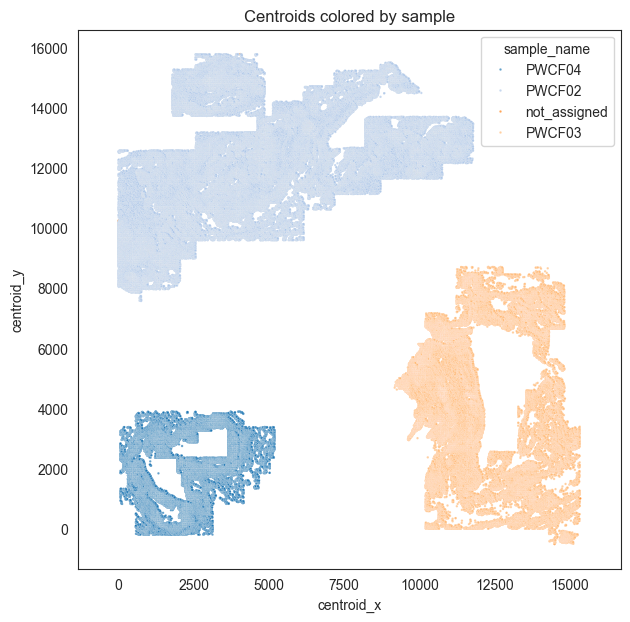

In [27]:
# scater plot using matplot lib
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))
sns.set_style("white")
sns.scatterplot(
    data=annotated_meta_slide,
    x="centroid_x",
    y="centroid_y",
    hue="sample_name",        # or "library_id", etc.
    s=3,
    alpha=0.7,
    palette="tab20"      # or any seaborn/matplotlib palette
)
plt.axis("equal")
plt.title("Centroids colored by sample")
plt.show()

In [28]:
annotated_meta_slide.groupby(["slide_ID", "sample_name"]).size().reset_index(name="count")

,slide_ID,sample_name,count
0,SLIDE02,PWCF02,224534
1,SLIDE02,PWCF03,125349
2,SLIDE02,PWCF04,81369
3,SLIDE02,not_assigned,4


## save the annotated metadata

In [29]:
# Save the annotated metadata
annotated_meta_slide.to_csv(meta_path, index=False)

In [30]:
# check if the saved file is correct
meta = pd.read_csv(meta_path)
meta

,cell,original_cell_id,centroid_x,centroid_y,centroid_z,component,volume,surface_area,scale,slide_ID,cell_id,sample_name
0,0,c_2_330_1737,581.47090,-167.37305,0.183252,2,25.75,184.0,1.0,SLIDE02,SLIDE02_0,PWCF04
1,1,c_2_330_1731,595.91724,-166.23209,0.173561,5,34.75,184.0,1.0,SLIDE02,SLIDE02_1,PWCF04
2,2,c_2_330_1752,614.08215,-168.41652,0.144953,2,53.25,212.0,1.0,SLIDE02,SLIDE02_2,PWCF04
3,3,c_2_330_1757,629.12964,-172.76375,0.127315,7,27.00,128.0,1.0,SLIDE02,SLIDE02_3,PWCF04
4,4,c_2_330_1777,640.08185,-180.33864,0.374091,5,68.75,356.0,1.0,SLIDE02,SLIDE02_4,PWCF04
...,...,...,...,...,...,...,...,...,...,...,...,...
431251,431251,c_2_172_92,14775.27900,8083.15530,0.767193,2,134.50,446.0,1.0,SLIDE02,SLIDE02_431251,PWCF03
431252,431252,c_2_172_129,14795.70200,8062.45000,0.577020,5,74.25,378.0,1.0,SLIDE02,SLIDE02_431252,PWCF03
431253,431253,c_2_172_123,14797.48000,8074.53000,0.709158,2,50.50,296.0,1.0,SLIDE02,SLIDE02_431253,PWCF03
431254,431254,c_2_172_86,14795.64100,8090.45070,0.769649,8,74.75,300.0,1.0,SLIDE02,SLIDE02_431254,PWCF03
